# SmartCart - Notebook 4: Visualization Dashboard

This notebook presents a compact dashboard for recommendation diagnostics and business-facing insights.

## Dashboard Views
- User similarity heatmap (top active users)
- Top-5 recommended products for each user group

## Inputs
- `data/processed/user_data_clean.csv`
- `data/processed/product_data_clean.csv`
- `data/processed/user_item_matrix_filled.csv`
- `data/processed/user_category_agg.csv`

Run Notebook 1 first to generate these processed artifacts.

In [1]:
# Imports
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

In [2]:
# Load processed artifacts
cwd = Path.cwd()
processed_candidates = [cwd / 'data' / 'processed', cwd.parent / 'data' / 'processed']
processed_dir = next((p for p in processed_candidates if p.exists()), processed_candidates[0])
required_files = [
    'user_data_clean.csv',
    'product_data_clean.csv',
    'user_item_matrix_filled.csv',
    'user_category_agg.csv',
]

missing = [f for f in required_files if not (processed_dir / f).exists()]
if missing:
    raise FileNotFoundError(
        'Missing processed files. Run Notebook 1 first. Missing: ' + ', '.join(missing) + 
        f'. Current working directory: {cwd}'
    )

user_data = pd.read_csv(processed_dir / 'user_data_clean.csv', parse_dates=['Timestamp'])
product_data = pd.read_csv(processed_dir / 'product_data_clean.csv')
user_item_matrix_filled = pd.read_csv(processed_dir / 'user_item_matrix_filled.csv', index_col=0).astype(np.float64)
user_category_agg = pd.read_csv(processed_dir / 'user_category_agg.csv', parse_dates=['LastInteraction'])

print('Loaded processed artifacts from:', processed_dir)
print('user_data shape:', user_data.shape)
print('product_data shape:', product_data.shape)
print('user_item_matrix shape:', user_item_matrix_filled.shape)
print('user_category_agg shape:', user_category_agg.shape)

Loaded processed artifacts from: /Users/solaris003/Repository/Projects/Recommender System & Pattern Mining for E-Commerce Analytics/data/processed
user_data shape: (724, 5)
product_data shape: (100, 3)
user_item_matrix shape: (50, 100)
user_category_agg shape: (272, 5)


In [3]:
# Utility functions used by dashboard views
def safe_cosine_similarity(matrix_like):
    matrix = np.asarray(matrix_like, dtype=np.float64)
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0)

    with warnings.catch_warnings():
        warnings.filterwarnings(
            'ignore',
            message='.*encountered in matmul',
            category=RuntimeWarning,
        )
        with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
            return cosine_similarity(matrix)

def recommend_top_n(
    target_user,
    ratings_matrix,
    user_similarity_df,
    n=5,
    neighbor_top_m=10,
    min_neighbor_similarity=0.0,
    min_pred_score=0.0,
    already_rated_threshold=0,
    return_scores=False,
):
    if target_user not in ratings_matrix.index:
        return [] if not return_scores else pd.DataFrame(columns=['ProductID', 'PredictedScore'])

    neighbors = (
        user_similarity_df.loc[target_user]
        .drop(index=target_user, errors='ignore')
        .sort_values(ascending=False)
    )
    neighbors = neighbors[neighbors > min_neighbor_similarity].head(neighbor_top_m)

    if neighbors.empty:
        return [] if not return_scores else pd.DataFrame(columns=['ProductID', 'PredictedScore'])

    neighbor_ratings = ratings_matrix.loc[neighbors.index]
    target_ratings = ratings_matrix.loc[target_user]

    unrated_items = target_ratings[target_ratings <= already_rated_threshold].index
    if len(unrated_items) == 0:
        return [] if not return_scores else pd.DataFrame(columns=['ProductID', 'PredictedScore'])

    weighted_sum = neighbor_ratings[unrated_items].T.dot(neighbors.values)
    sim_sum = np.abs(neighbors.values).sum()

    if sim_sum == 0:
        return [] if not return_scores else pd.DataFrame(columns=['ProductID', 'PredictedScore'])

    pred_scores = (weighted_sum / sim_sum).sort_values(ascending=False)
    pred_scores = pred_scores[pred_scores > min_pred_score]

    if return_scores:
        return pred_scores.head(n).rename('PredictedScore').reset_index().rename(columns={'index': 'ProductID'})

    return pred_scores.head(n).index.tolist()

In [4]:
# Compute user similarity matrix
similarity_matrix = safe_cosine_similarity(user_item_matrix_filled)
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=user_item_matrix_filled.index,
    columns=user_item_matrix_filled.index,
)

similarity_df.iloc[:5, :5]

UserID,U000,U001,U002,U003,U004
UserID,,,,,
U000,1.000000,0.063071,0.195522,0.023466,0.065412
U001,0.063071,1.000000,0.190861,0.000000,0.111332
U002,0.195522,0.190861,1.000000,0.065094,0.111662
U003,0.023466,0.000000,0.065094,1.000000,0.035737
U004,0.065412,0.111332,0.111662,0.035737,1.000000


## View 1: User Similarity Heatmap
This chart highlights similarity structure among the most active users, making user clusters easier to inspect visually.

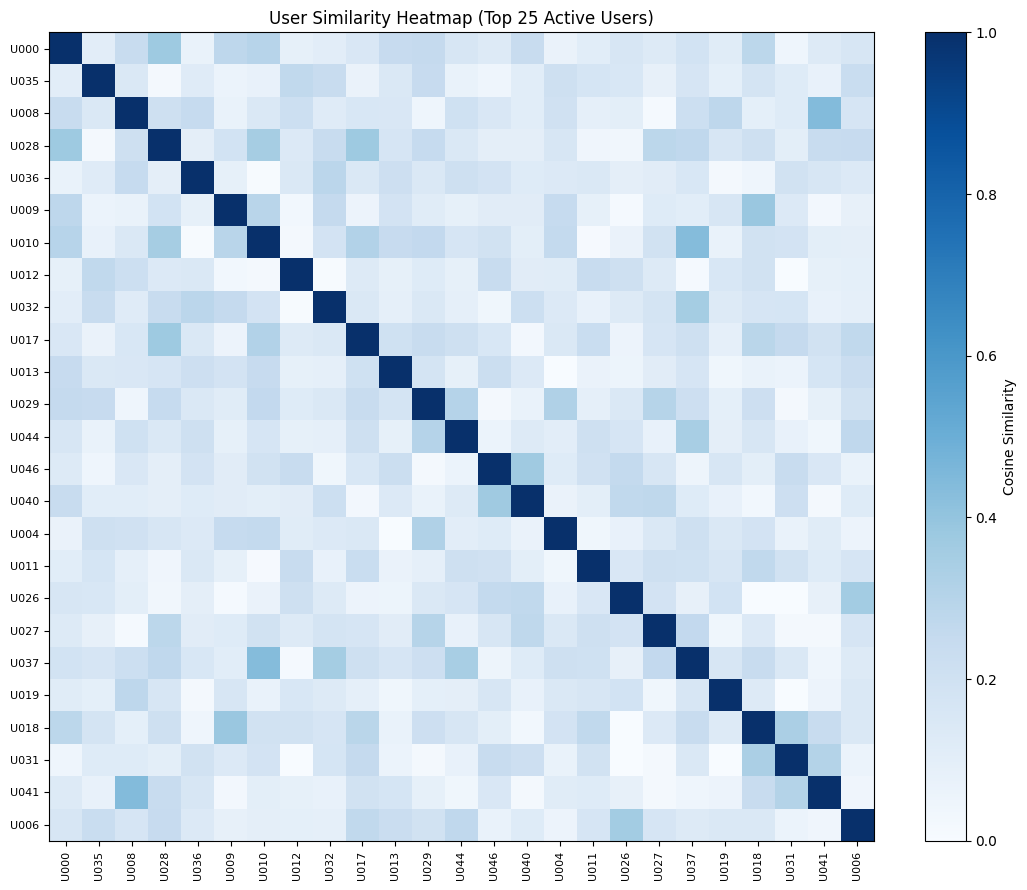

In [5]:
# Heatmap for top active users
user_activity = (user_item_matrix_filled > 0).sum(axis=1).sort_values(ascending=False)
top_n_users = min(25, len(user_activity))
selected_users = user_activity.head(top_n_users).index

sim_subset = similarity_df.loc[selected_users, selected_users]

plt.figure(figsize=(11, 9))
plt.imshow(sim_subset.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)
plt.colorbar(label='Cosine Similarity')
plt.title(f'User Similarity Heatmap (Top {top_n_users} Active Users)')
plt.xticks(range(top_n_users), selected_users, rotation=90, fontsize=8)
plt.yticks(range(top_n_users), selected_users, fontsize=8)
plt.tight_layout()
plt.show()

## View 2: Top-5 Products by User Group
Users are grouped by dominant category behavior, then recommendations are pooled to surface group-level top products.

Top-5 product recommendations per user group:


,UserGroup,GroupSize,ProductID,ProductName,AvgPredictedScore
0,Beauty,10,P0088,Clothing Item 88,1.579300
1,Beauty,10,P0070,Beauty Item 70,1.481122
2,Beauty,10,P0064,Electronics Item 64,1.291531
3,Beauty,10,P0013,Clothing Item 13,1.230362
4,Beauty,10,P0043,Books Item 43,1.182364
5,Books,18,P0070,Beauty Item 70,1.246305
6,Books,18,P0094,Toys Item 94,1.158550
7,Books,18,P0039,Toys Item 39,1.146201
8,Books,18,P0066,Home Item 66,1.135298
9,Books,18,P0051,Home Item 51,1.117287


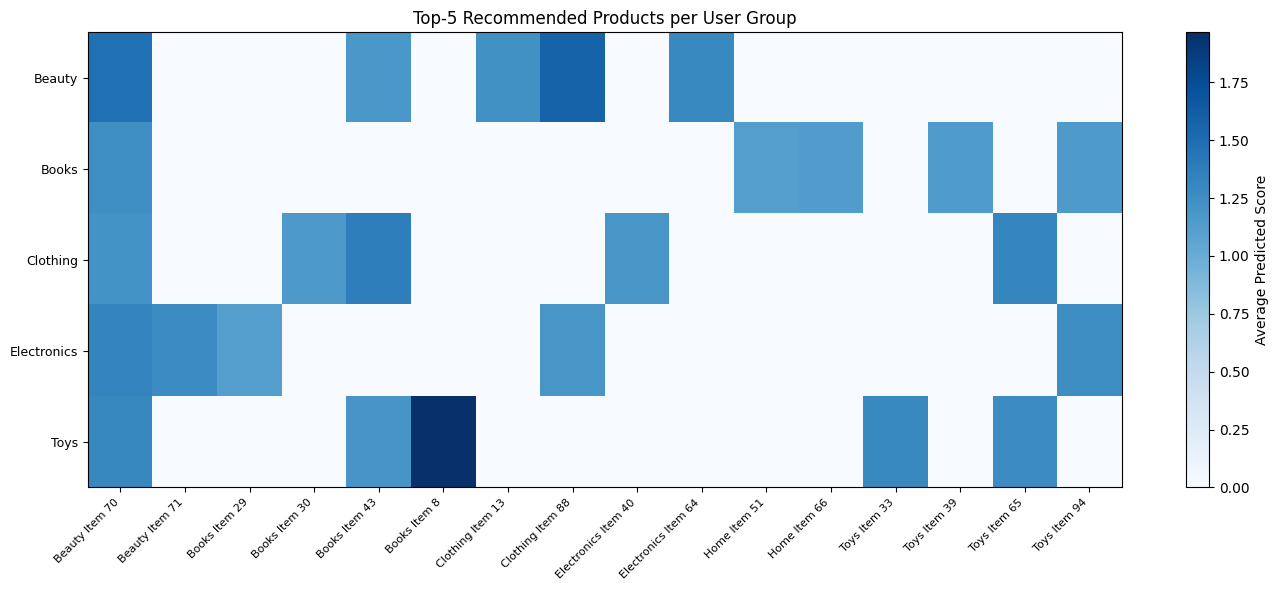

In [6]:
# Build user groups from dominant category
user_primary_group = (
    user_category_agg.sort_values(['UserID', 'TotalInteractions'], ascending=[True, False])
    .drop_duplicates(subset='UserID')
    .rename(columns={'Category': 'UserGroup'})[['UserID', 'UserGroup']]
)

product_name_map = product_data.set_index('ProductID')['ProductName'].to_dict()
group_recommendation_rows = []

for group_name, group_users_df in user_primary_group.groupby('UserGroup'):
    group_users = group_users_df['UserID'].tolist()

    score_accumulator = {}
    for user in group_users:
        rec_scores = recommend_top_n(
            target_user=user,
            ratings_matrix=user_item_matrix_filled,
            user_similarity_df=similarity_df,
            n=20,
            neighbor_top_m=10,
            min_neighbor_similarity=0.0,
            min_pred_score=0.0,
            already_rated_threshold=0,
            return_scores=True,
        )

        if rec_scores is None or rec_scores.empty:
            continue

        for _, rec in rec_scores.iterrows():
            pid = rec['ProductID']
            score_accumulator.setdefault(pid, []).append(float(rec['PredictedScore']))

    if len(score_accumulator) == 0:
        continue

    group_top = (
        pd.DataFrame({
            'ProductID': list(score_accumulator.keys()),
            'AvgPredictedScore': [np.mean(v) for v in score_accumulator.values()],
        })
        .sort_values('AvgPredictedScore', ascending=False)
        .head(5)
        .reset_index(drop=True)
    )

    group_top['UserGroup'] = group_name
    group_top['ProductName'] = group_top['ProductID'].map(product_name_map).fillna(group_top['ProductID'])
    group_top['GroupSize'] = len(group_users)
    group_recommendation_rows.append(group_top)

if group_recommendation_rows:
    group_recommendations = pd.concat(group_recommendation_rows, ignore_index=True)
    group_recommendations = group_recommendations[
        ['UserGroup', 'GroupSize', 'ProductID', 'ProductName', 'AvgPredictedScore']
    ]

    print('Top-5 product recommendations per user group:')
    display(group_recommendations.sort_values(['UserGroup', 'AvgPredictedScore'], ascending=[True, False]))

    pivot_scores = group_recommendations.pivot_table(
        index='UserGroup',
        columns='ProductName',
        values='AvgPredictedScore',
        aggfunc='mean'
    ).fillna(0)

    plt.figure(figsize=(14, 6))
    plt.imshow(pivot_scores.values, cmap='Blues', aspect='auto')
    plt.colorbar(label='Average Predicted Score')
    plt.title('Top-5 Recommended Products per User Group')
    plt.xticks(range(len(pivot_scores.columns)), pivot_scores.columns, rotation=45, ha='right', fontsize=8)
    plt.yticks(range(len(pivot_scores.index)), pivot_scores.index, fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No group recommendations could be generated with current settings.')

## How To Use This Dashboard
- Use View 1 to identify dense or sparse user neighborhoods.
- Use View 2 to prepare segment-specific campaigns and featured bundles.
- Compare these outputs against Notebook 2 metrics before deployment decisions.